# General notebook

In [1]:
using Revise
Revise.retry() # Just in case if only Revise is not sufficient. 
include("lattice_protein.jl")

Imports done, importing hamiltonian path
Starting backtracking
Calculation of all conformations
Step 1: Exploration from the corner (node 1)
Step 2: Exploration from the center of the face (node 5)
hamiltonian path imported, importing metropolis
metropolis imported, importing benchmark
benchmark imported, importing visualization
visualization imported, importing tree
tree imported, importing lattice_protein


## Hamiltonian paths

In [2]:
println("We find $(length(PATHS)) unique paths.")
println(first(PATHS))

We find 103346 unique paths.
Int8[1, 2, 3, 6, 5, 4, 7, 8, 9, 18, 17, 16, 13, 14, 15, 12, 11, 10, 19, 20, 21, 24, 23, 22, 25, 26, 27]


Contact map for the first path:
Path visualization for the 75005:


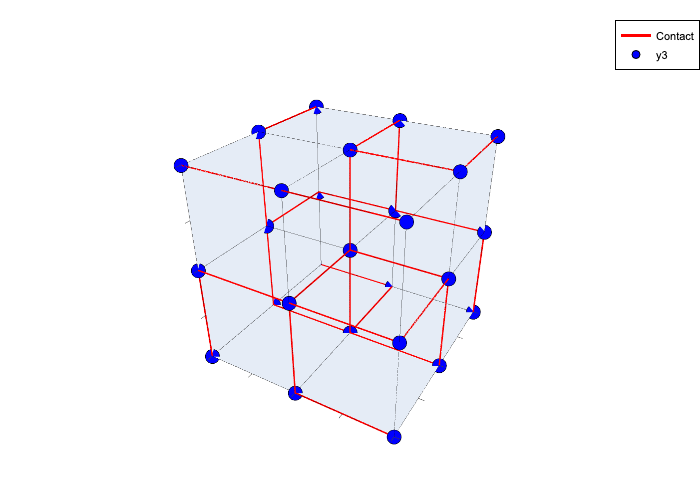

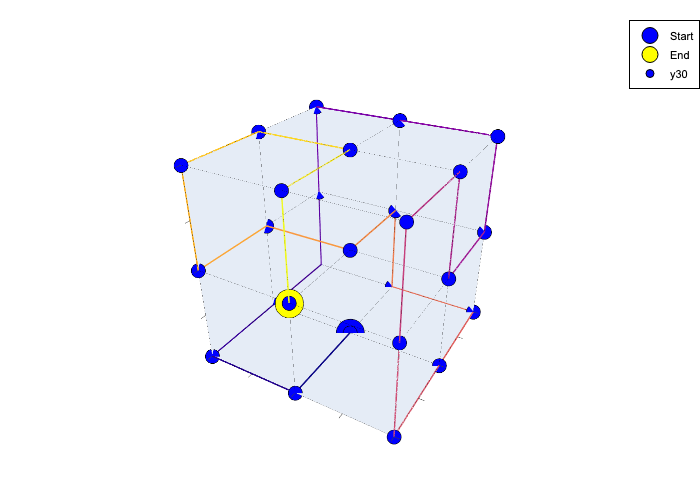

In [18]:
println("Contact map for the first path:")
liste_contact = contact_map(PATHS[75005])
display(plot_cube_ctc_map(x, y, z, lx, ly, lz, liste_contact))

println("Path visualization for the 75005:")
display(plot_cube_path(x, y, z, lx, ly, lz, PATHS[75005]))

## Metropolis general results

Attention : si on veut changer de matrice (MJ*5 ou MJ_1996) il faut restart le kernel et modifier la ligne const dans le ficher metropolis.jl. 

MJ*5

algo (β=100) 100%|███████████████████████████████████████| Time: 0:01:18


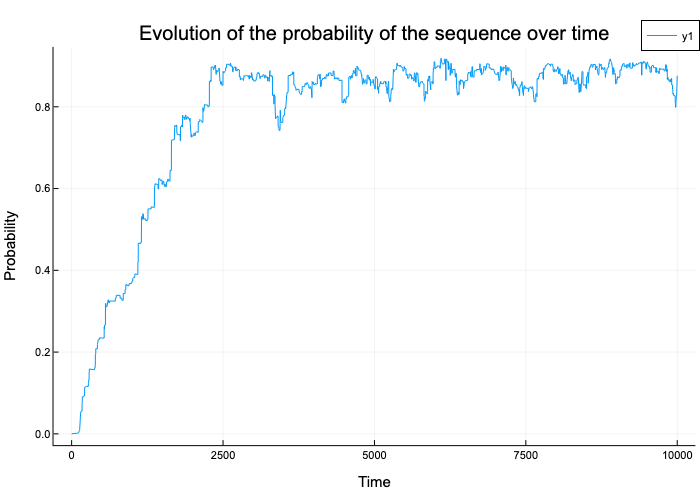

In [19]:
# with all the data
seq = generate_seq()
print(matrix_name)
target_number = 75005
all_ctc_maps = all_contact_maps(PATHS)
plot_probability(seq, target_number, all_ctc_maps, 10000)

MJ*5

algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:07


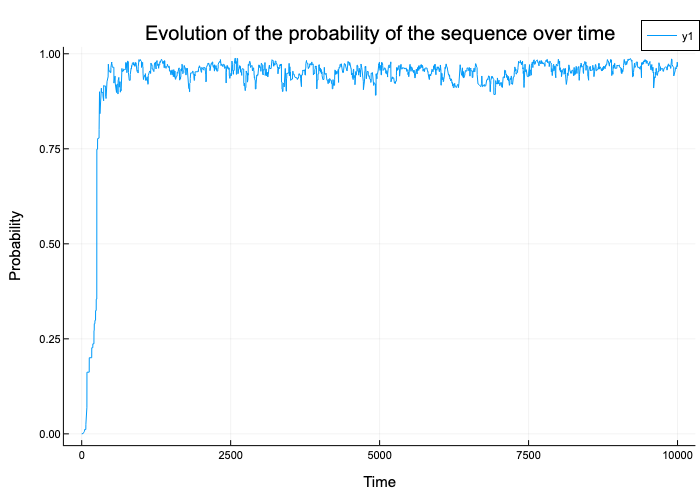

In [3]:
# with few data
paths_reduced = reduce_data(PATHS, 10)
seq = generate_seq()
target_number = 1234
print(matrix_name)

all_ctc_maps = all_contact_maps(paths_reduced)
plot_probability(seq, target_number, all_ctc_maps, 10000)

Testing beta = 10


algo (β=10) 100%|████████████████████████████████████████| Time: 0:00:03


Testing beta = 50


algo (β=50) 100%|████████████████████████████████████████| Time: 0:00:02


Testing beta = 100


algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:03


Testing beta = 1000


algo (β=1000) 100%|██████████████████████████████████████| Time: 0:00:02


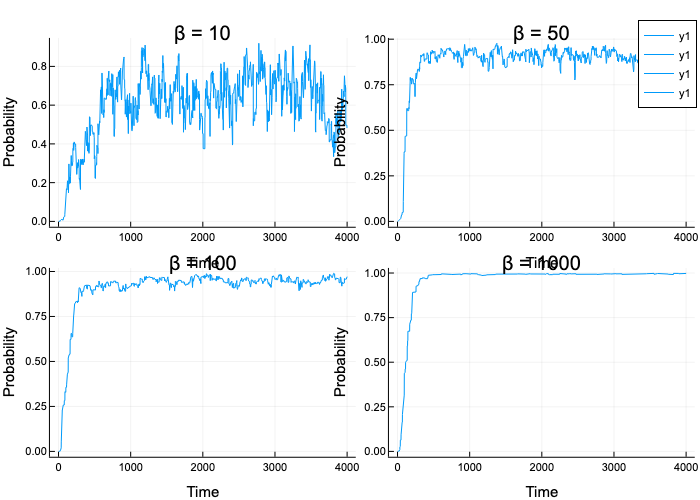

Dict{Float64, Tuple{Vector{Int64}, Vector{Float64}}} with 4 entries:
  50.0   => ([7, 12, 18, 18, 10, 2, 15, 6, 15, 12  …  19, 12, 16, 19, 3, 15, 4,…
  10.0   => ([5, 10, 18, 6, 16, 19, 4, 12, 18, 6  …  15, 6, 1, 5, 15, 1, 19, 7,…
  1000.0 => ([19, 20, 19, 17, 19, 7, 17, 15, 16, 19  …  19, 15, 19, 16, 1, 15, …
  100.0  => ([11, 15, 5, 16, 13, 4, 19, 20, 14, 19  …  19, 12, 17, 16, 5, 16, 1…

In [21]:
paths_reduced = reduce_data(PATHS, 10)
seq = generate_seq()
target_number = 1234
all_ctc_maps = all_contact_maps(paths_reduced)


benchmark_beta()

## Further observations

### Chain evolution

ici

Multi-init 100%|█████████████████████████████████████████| Time: 0:00:22


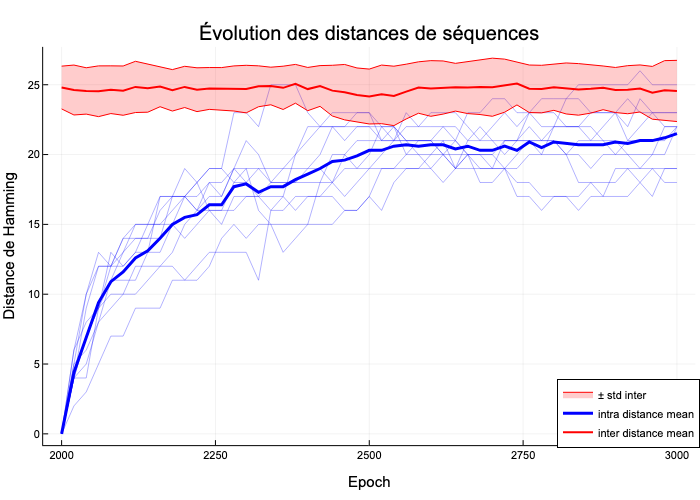

In [5]:
paths_reduced = reduce_data(PATHS, 10)
beta = 100.0

seq_over_time = multi_init_seq_over_time(target_number, all_ctc_maps, epochs=3000, beta=beta, threshold=2000, step=20, runs=10)
plot_distances_inter_intra(seq_over_time, beta=beta)

### All proba

In [23]:
final_seq, p_struct_time_t, p_final,_=algo_show_probability_distribution(seq, target_number, all_ctc_maps, 10000, 100)
show_sorted_indices(p_final)

algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:06


structure 1234 : 0.977278123287559
structure 1558 : 0.004640264097790803
structure 529 : 0.003437592192418624
structure 1797 : 0.002191905555681305
structure 3084 : 0.0017945804862787762
structure 493 : 0.0008476997979198011
structure 5133 : 0.0007670304964193603
structure 5048 : 0.000729621977683493
structure 5033 : 0.000729621977683482
structure 557 : 0.0005405172552777555
structure 1237 : 0.00040042503130262796
structure 10031 : 0.00031185132793988427
structure 1253 : 0.0002821747503842053
structure 1208 : 0.0002821747503842036
structure 1220 : 0.0002684129254166014
structure 7760 : 0.0002428700584014369
structure 4804 : 0.0002197579165621944
structure 5147 : 0.00020904019650093582
structure 1158 : 0.00019884518581509916
structure 3928 : 0.00018914739166763392


## Tree generation

In [24]:
paths_reduced = reduce_data(PATHS, 10)
seq = generate_seq()
target_number = 1234
all_ctc_maps = all_contact_maps(paths_reduced)

root,_,_ = algo(seq, target_number, all_ctc_maps, 5000, 100, 10000, 200, true)
newick, seq_dict = create_genealogy(root, 50, 2, target_number, all_ctc_maps)

println(newick)

# Charger l'arbre dans TreeTools
tree = parse_newick_string(newick)

for node in nodes(tree)
    name = label(node)
    println("$name : $(seq_dict[name])")
end

algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:03


((N3:50,N4:50)N2:50,(N6:50,N7:50)N5:50)N1;
N3 : [4, 10, 16, 15, 1, 9, 19, 17, 18, 13, 16, 19, 6, 18, 20, 5, 19, 15, 18, 4, 5, 4, 12, 11, 4, 15, 15]
N4 : [13, 10, 15, 15, 1, 4, 19, 6, 18, 13, 16, 19, 2, 18, 3, 6, 19, 15, 19, 2, 1, 4, 12, 8, 2, 11, 15]
N5 : [1, 15, 16, 15, 5, 6, 19, 20, 18, 7, 16, 19, 5, 18, 2, 5, 19, 16, 18, 2, 1, 3, 18, 19, 3, 15, 15]
N7 : [1, 2, 16, 15, 5, 6, 19, 20, 18, 13, 16, 19, 5, 18, 2, 5, 19, 16, 18, 1, 5, 2, 18, 4, 3, 15, 7]
N1 : [1, 6, 16, 15, 5, 3, 19, 20, 18, 7, 16, 19, 3, 18, 2, 5, 19, 16, 18, 10, 1, 3, 10, 8, 5, 15, 15]
N6 : [1, 15, 16, 15, 5, 6, 19, 20, 18, 11, 16, 19, 4, 18, 3, 5, 19, 16, 18, 2, 1, 3, 18, 2, 3, 15, 1]
N2 : [3, 10, 16, 15, 1, 4, 19, 5, 18, 13, 16, 19, 3, 18, 2, 5, 19, 15, 18, 2, 1, 4, 12, 8, 2, 15, 15]


In [25]:
simple_print_distance_matrix(seq_dict)

     N3    N4    N5    N7    N1    N6    N2    
N3   0     13    15    14    15    16    9     
N4   13    0     17    19    17    17    8     
N5   15    17    0     7     7     5     12    
N7   14    19    7     0     11    9     14    
N1   15    17    7     11    0     10    11    
N6   16    17    5     9     10    0     14    
N2   9     8     12    14    11    14    0     


In [26]:
p = plot_distance_matrix(seq_dict)
savefig(p, "../figures/distance_matrix.svg")

"/Users/marie.gabilly/Documents/master/m1/s2/projet/figures/distance_matrix.svg"

In [27]:
#je n'ai pas trouvé de fonction pour afficher l'arbre dans treetools